In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path(__file__).resolve().parents[1])) # Ensure the repo root is on sys.path so sibling packages like `prompt_templates` can be imported


NameError: name '__file__' is not defined

# Testing Supervisor Agent

In [ ]:
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage
load_dotenv("config/.env")

from context import DatasetContext
from agents.supervisor_agent import run_supervisor
from structured_outputs import SupervisorOutput, SupervisorAction

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description="Monthly snapshot of active mobile subscribers Q3 2024.",
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=["enterprise segment has only ~30 records — small sample"]
)


def test_vague_question():
    """Vague question should return CLARIFY."""
    print("\n" + "="*60)
    print("TEST 1 — Vague question")
    print("="*60)
    result = run_supervisor(user_message="can you look at my data", context=context)
    print(f"Action:    {result.action}")
    print(f"Reasoning: {result.reasoning}")
    if result.is_clarify():
        print(f"Question:  {result.clarifying_question}")
        print("✓ PASS")
    else:
        print(f"Improved:  {result.improved_questions}")
        print("✗ FAIL — expected CLARIFY")


def test_single_clear_question():
    """Single clear question should return HANDOFF with one improved question."""
    print("\n" + "="*60)
    print("TEST 2 — Single clear question")
    print("="*60)
    result = run_supervisor(
        user_message="what is the churn rate for each plan type",
        context=context,
    )
    print(f"Action: {result.action}")
    if result.is_handoff():
        print(f"Improved questions: {result.improved_questions}")
        assert len(result.improved_questions) == 1
        assert "churn" in result.improved_questions[0].lower()
        assert "plan_type" in result.improved_questions[0].lower()
        print("✓ PASS")
    else:
        print(f"Question: {result.clarifying_question}")
        print("✗ FAIL — expected HANDOFF")


def test_multiple_questions():
    """Multiple questions should all be improved and returned as a list."""
    print("\n" + "="*60)
    print("TEST 3 — Multiple questions")
    print("="*60)
    result = run_supervisor(
        user_message=(
            "1. What is the churn rate by plan type?\n"
            "2. Is there a significant difference in arpu between churned and retained customers?\n"
            "3. Which customers have the highest credits values?"
        ),
        context=context,
    )
    print(f"Action: {result.action}")
    if result.is_handoff():
        print(f"Improved questions ({len(result.improved_questions)}):")
        for i, q in enumerate(result.improved_questions, 1):
            print(f"  {i}. {q}")
        assert len(result.improved_questions) == 3, \
            f"Expected 3 questions, got {len(result.improved_questions)}"
        print("✓ PASS")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")
        print("✗ FAIL — expected HANDOFF")


def test_multi_turn():
    """Second message resolves to HANDOFF after clarification."""
    print("\n" + "="*60)
    print("TEST 4 — Multi-turn conversation")
    print("="*60)
    result1 = run_supervisor(user_message="analyse my data", context=context)
    print(f"Turn 1 — {result1.action}")
    if result1.is_clarify():
        print(f"Question: {result1.clarifying_question}")

    history = [
        HumanMessage(content="analyse my data"),
        AIMessage(content=result1.clarifying_question or ""),
    ]
    result2 = run_supervisor(
        user_message="I want to know which plan type has the highest churn rate",
        context=context,
        conversation_history=history,
    )
    print(f"Turn 2 — {result2.action}")
    if result2.is_handoff():
        print(f"Improved: {result2.improved_questions}")
        print("✓ PASS")
    else:
        print(f"Still clarifying: {result2.clarifying_question}")
        print("✗ FAIL")


if __name__ == "__main__":
    test_vague_question()
    test_single_clear_question()
    test_multiple_questions()
    test_multi_turn()


TEST 1 — Vague question
Action:    SupervisorAction.CLARIFY
Reasoning: The request to 'look at my data' is vague and does not specify what analysis or insight is desired.
Question:  What specific analysis or insights are you looking for from the data?
✓ PASS

TEST 2 — Single clear question
Action: SupervisorAction.HANDOFF
Improved questions: ["What is the churn rate for each 'plan_type' in the dataset, calculated as the number of churned users divided by the total number of users for each plan type?"]
✓ PASS

TEST 3 — Multiple questions
Action: SupervisorAction.HANDOFF
Improved questions (3):
  1. What is the churn rate calculated as the percentage of churned customers by each plan_type?
  2. Is there a statistically significant difference in arpu between customers with churn = 1 and churn = 0?
  3. Which customers have the highest credits values, indicating potential billing disputes or service failures?
✓ PASS

TEST 4 — Multi-turn conversation
Turn 1 — SupervisorAction.CLARIFY
Quest

# Testing Planner Agent


In [3]:
"""
Note: These tests require a real CSV file at the path in DatasetContext.
Create a small test CSV before running:
"""

import pandas as pd, numpy as np
pd.DataFrame({
    "churn":         np.random.binomial(1, 0.2, 100),
    "arpu":          np.random.normal(55, 15, 100).clip(5),
    "tenure_months": np.random.randint(1, 60, 100),
    "plan_type":     np.random.choice(["prepaid","postpaid","enterprise"], 100),
    "credits":       np.random.exponential(10, 100)
}).to_csv("data/churn.csv", index=False)

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

load_dotenv("config/.env")

from context import DatasetContext
from agents.planner_agent import run_planner
from structured_outputs import PlannerOutput, PlannerAction, AgentType


# ── Create test CSV if it doesn't exist ──────────────────────────────────────

def _ensure_test_csv():
    path = Path("data/churn.csv")
    if not path.exists():
        path.parent.mkdir(exist_ok=True)
        np.random.seed(42)
        n = 200
        pd.DataFrame({
            "churn":         np.random.binomial(1, 0.2, n),
            "arpu":          np.random.normal(55, 15, n).clip(5),
            "tenure_months": np.random.randint(1, 60, n),
            "plan_type":     np.random.choice(
                                 ["prepaid", "postpaid", "enterprise"], n,
                                 p=[0.5, 0.35, 0.15]
                             ),
            "credits":       np.random.exponential(10, n),
        }).to_csv(path, index=False)
        print(f"Created test CSV at {path}")


# ── Shared context ────────────────────────────────────────────────────────────

_ensure_test_csv()

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description=(
        "Monthly snapshot of active mobile subscribers Q3 2024. "
        "Each row is one customer account."
    ),
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=[
        "enterprise segment has only ~30 records — small sample",
    ]
)


# ── Tests ─────────────────────────────────────────────────────────────────────

def test_produces_plan():
    """A clear question should produce a PLAN with steps."""
    print("\n" + "="*60)
    print("TEST 1 — Produces a plan")
    print("="*60)

    result = run_planner(
        improved_question=(
            "What is the churn rate (proportion where churn = 1) broken "
            "down by plan_type? Which segment has the highest churn rate?"
        ),
        context=context,
    )

    print(f"Action: {result.action}")

    if result.is_plan():
        print(f"Goal:   {result.goal}")
        print(f"Steps:  {len(result.steps)}")
        for step in result.steps:
            print(f"  Step {step.id} [{step.agent.value}] — {step.title}")
        print(f"Risks:  {result.risks}")
        print("✓ PASS")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")
        print("✗ FAIL — expected PLAN")


def test_plan_has_correct_agents():
    """
    A question requiring computation and visualization should assign
    the right agents to the right steps.
    """
    print("\n" + "="*60)
    print("TEST 2 — Correct agents assigned")
    print("="*60)

    result = run_planner(
        improved_question=(
            "What is the churn rate by plan_type? "
            "Show the result as a bar chart."
        ),
        context=context,
    )

    print(f"Action: {result.action}")

    if result.is_plan():
        for step in result.steps:
            print(f"  Step {step.id} [{step.agent.value}] — {step.title}")

        agents_used = {step.agent for step in result.steps}
        has_coder  = AgentType.CODER      in agents_used
        has_viz    = AgentType.VISUALIZER in agents_used

        print(f"\nHas coder step:      {'✓' if has_coder else '✗'}")
        print(f"Has visualizer step: {'✓' if has_viz   else '✗'}")
        print("✓ PASS" if has_coder and has_viz else "✗ FAIL")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")
        print("✗ FAIL — expected PLAN")


def test_plan_references_real_columns():
    """
    Steps should reference actual column names from the dataset,
    not generic placeholders.
    """
    print("\n" + "="*60)
    print("TEST 3 — Steps reference real column names")
    print("="*60)

    result = run_planner(
        improved_question=(
            "Is there a significant difference in arpu between "
            "churned (churn=1) and retained (churn=0) customers?"
        ),
        context=context,
    )

    print(f"Action: {result.action}")

    if result.is_plan():
        all_inputs = []
        for step in result.steps:
            all_inputs.extend(step.inputs)
            print(f"  Step {step.id} inputs: {step.inputs}")

        has_churn = any("churn" in i.lower() for i in all_inputs)
        has_arpu  = any("arpu"  in i.lower() for i in all_inputs)

        print(f"\nInputs reference 'churn': {'✓' if has_churn else '✗'}")
        print(f"Inputs reference 'arpu':  {'✓' if has_arpu  else '✗'}")
        print("✓ PASS" if has_churn and has_arpu else "✗ FAIL")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")


def test_business_rules_in_steps():
    """
    Steps involving the credits column should carry the business rule note.
    """
    print("\n" + "="*60)
    print("TEST 4 — Business rules in relevant steps")
    print("="*60)

    result = run_planner(
        improved_question=(
            "Which customers have the highest credits values? "
            "Note that high credits indicate billing disputes (bad signal)."
        ),
        context=context,
    )

    print(f"Action: {result.action}")

    if result.is_plan():
        for step in result.steps:
            print(f"  Step {step.id} — {step.title}")
            print(f"    business_rule_notes: {step.business_rule_notes}")

        has_rule = any(
            step.business_rule_notes and
            ("credit" in step.business_rule_notes.lower() or
             "bad"    in step.business_rule_notes.lower())
            for step in result.steps
        )
        print(f"\nBusiness rule in a step: {'✓' if has_rule else '✗'}")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")


if __name__ == "__main__":
    test_produces_plan()
    test_plan_has_correct_agents()
    test_plan_references_real_columns()
    test_business_rules_in_steps()


TEST 1 — Produces a plan


KeyboardInterrupt: 

# Testing: Supervisor -> Planner Communication

In [2]:


from dotenv import load_dotenv
load_dotenv("config/.env")

from langgraph.types import Command

from context import DatasetContext
from workflow.state import AgentState
from workflow.graph import build_graph


# ── Shared context ────────────────────────────────────────────────────────────

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description=(
        "Monthly snapshot of active mobile subscribers Q3 2024. "
        "Each row is one customer account."
    ),
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=[
        "enterprise segment has only ~30 records — small sample",
    ]
)


def test_supervisor_to_planner():
    """
    Full flow: user question → supervisor → planner → human_approval interrupt.
    Verifies the graph pauses at human_approval with the plan.
    """
    print("\n" + "="*60)
    print("TEST 1 — Supervisor → Planner → Human approval interrupt")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-1"}}

    # Initial invocation
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "What is the churn rate by plan type?"}],
            "improved_questions": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
            "planner_clarification": None,   # ← add this
        },
        config=config,
        version="v2",
    )

    print(f"Result type: {type(result).__name__}")

    # Should have paused at human_approval
    if hasattr(result, "interrupts") and result.interrupts:
        interrupt_payload = result.interrupts[0].value
        print(f"Interrupted with: {interrupt_payload['message']}")
        plan_data = interrupt_payload.get("plan")
        if plan_data:
            print(f"Plan goal: {plan_data.get('goal')}")
            print(f"Steps: {len(plan_data.get('steps', []))}")
            for step in plan_data.get("steps", []):
                print(f"  Step {step['id']} [{step['agent']}] — {step['title']}")
        print("✓ PASS — graph paused at human_approval")
    else:
        print(f"Result value: {result}")
        print("✗ FAIL — expected interrupt at human_approval")


def test_approve_and_execute():
    """
    Full flow including human approval and placeholder execution.
    """
    print("\n" + "="*60)
    print("TEST 2 — Approve plan and execute steps")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-2"}}

    # First invocation — runs to interrupt
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "What is the churn rate by plan type? Show as a bar chart."}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    if not hasattr(result, "interrupts") or not result.interrupts:
        print("✗ FAIL — expected interrupt, got:", result)
        return

    print(f"Plan received — approving...")

    # Resume with approval
    final_result = graph.invoke(
        Command(resume={"approved": True, "plan": result.interrupts[0].value.get("plan")}),
        config=config,
        version="v2",
    )

    print(f"Final result type: {type(final_result).__name__}")

    # Get final state
    state = final_result.value if hasattr(final_result, "value") else final_result
    if isinstance(state, dict):
        print(f"Final report: {state.get('final_report')}")
        print(f"Step results: {state.get('step_results')}")
        if state.get("final_report"):
            print("✓ PASS — workflow completed")
        else:
            print("✗ FAIL — no final report")


def test_vague_question_clarification():
    """
    Vague question should trigger clarification — graph pauses at END
    waiting for user response.
    """
    print("\n" + "="*60)
    print("TEST 3 — Vague question triggers clarification")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-3"}}

    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "analyse my data"}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    state = result.value if hasattr(result, "value") else result
    if isinstance(state, dict):
        messages = state.get("messages", [])
        last_msg = messages[-1] if messages else None
        if last_msg:
            content = getattr(last_msg, "content", str(last_msg))
            print(f"Last message: {content}")
            print("✓ PASS — supervisor asked for clarification")


if __name__ == "__main__":
    test_supervisor_to_planner()
    test_approve_and_execute()
    test_vague_question_clarification()



TEST 1 — Supervisor → Planner → Human approval interrupt

[Supervisor] Original question: What is the churn rate by plan type?
[Supervisor] Improved questions:
  1. What is the churn rate, defined as the percentage of churned customers, grouped by the 'plan_type' column?
[Planner] Plan ready — 3 steps
Result type: GraphOutput
Interrupted with: Please review the analysis plan.
Plan goal: Calculate the churn rate grouped by plan type in the churn dataset.
Steps: 3
  Step 1 [AgentType.CODER] — Compute churn rate by plan_type
  Step 2 [AgentType.VISUALIZER] — Visualize churn rate by plan_type
  Step 3 [AgentType.REPORTER] — Compile final report
✓ PASS — graph paused at human_approval

TEST 2 — Approve plan and execute steps

[Supervisor] Original question: What is the churn rate by plan type? Show as a bar chart.
[Supervisor] Improved questions:
  1. What is the churn rate (percentage of churned customers) by plan type (prepaid, postpaid, enterprise)? Please present the results as a bar c

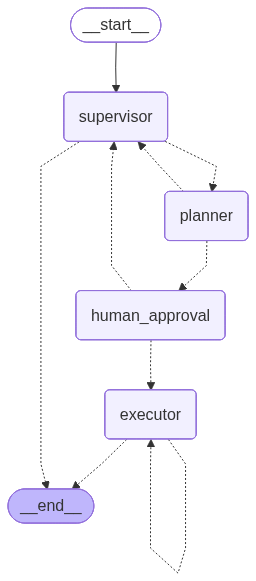

In [5]:
from IPython.display import Image, display
graph = build_graph(context=context)
display(Image(graph.get_graph().draw_mermaid_png()))

# Testing - Coder Agent

In [1]:
"""
tests/test_coder.py

Tests for the coder agent.

Run from project root:
    python -m tests.test_coder
"""

from dotenv import load_dotenv
load_dotenv("config/.env")

from context import DatasetContext
from structured_outputs.planner_output import AnalysisStep
from structured_outputs.base import AgentType
from agents.coder_agent import run_coder


context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description="Monthly snapshot of active mobile subscribers Q3 2024.",
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=["enterprise segment has only ~30 records — small sample"]
)


def test_churn_rate_by_plan():
    """Coder should compute churn rate grouped by plan_type."""
    print("\n" + "="*60)
    print("TEST 1 — Churn rate by plan type")
    print("="*60)

    step = AnalysisStep(
        id=1,
        title="Compute churn rate by plan type",
        description=(
            "Group customers by plan_type and compute the churn rate "
            "(proportion where churn = 1) for each group."
        ),
        agent=AgentType.CODER,
        inputs=["plan_type", "churn"],
        expected_output="Dict mapping each plan_type to its churn rate",
        depends_on=[],
        business_rule_notes="churn = 1 is a bad outcome — higher rate = worse performance",
    )

    result = run_coder(step=step, context=context)

    print(f"Success: {result.success}")
    print(f"Summary:\n{result.summary}")
    if result.error:
        print(f"Error: {result.error}")

    assert result.success, f"Expected success, got error: {result.error}"
    assert result.summary is not None
    print("✓ PASS")


def test_average_arpu_by_churn():
    """Coder should compute mean ARPU for churned vs retained customers."""
    print("\n" + "="*60)
    print("TEST 2 — Average ARPU by churn status")
    print("="*60)

    step = AnalysisStep(
        id=1,
        title="Compare ARPU churned vs retained",
        description=(
            "Compute the mean arpu for customers where churn = 1 "
            "and where churn = 0 separately."
        ),
        agent=AgentType.CODER,
        inputs=["arpu", "churn"],
        expected_output="Dict with keys 'churned' and 'retained' mapping to mean arpu values",
        depends_on=[],
        business_rule_notes="arpu: higher = better. Churned customers having lower arpu may indicate price sensitivity.",
    )

    result = run_coder(step=step, context=context)

    print(f"Success: {result.success}")
    print(f"Summary:\n{result.summary}")

    assert result.success, f"Expected success, got error: {result.error}"
    print("✓ PASS")


def test_top_credits_customers():
    """Coder should identify top customers by credits with business rule applied."""
    print("\n" + "="*60)
    print("TEST 3 — Top customers by credits (business rule)")
    print("="*60)

    step = AnalysisStep(
        id=1,
        title="Find top credits customers",
        description=(
            "Identify the top 10 customers by credits value. "
            "High credits indicate billing disputes."
        ),
        agent=AgentType.CODER,
        inputs=["customer_id", "credits"] if "customer_id" in [] else ["credits"],
        expected_output="Top 10 rows sorted by credits descending",
        depends_on=[],
        business_rule_notes="credits: high = bad — these customers are experiencing billing issues",
    )

    result = run_coder(step=step, context=context)

    print(f"Success: {result.success}")
    print(f"Summary:\n{result.summary}")

    assert result.success, f"Expected success, got error: {result.error}"
    assert result.summary is not None
    # Business rule should be mentioned in the summary
    has_rule = any(
        term in (result.summary or "").lower()
        for term in ["billing", "dispute", "bad", "negative"]
    )
    print(f"Business rule in summary: {'✓' if has_rule else '✗'}")
    print("✓ PASS")


def test_uses_previous_step_result():
    """Coder should be able to use output from a previous step."""
    print("\n" + "="*60)
    print("TEST 4 — Uses previous step result")
    print("="*60)

    step = AnalysisStep(
        id=2,
        title="Find highest churn segment",
        description=(
            "Using the churn rates by plan_type from step 1, "
            "identify which plan_type has the highest churn rate."
        ),
        agent=AgentType.CODER,
        inputs=["output of step 1"],
        expected_output="The plan_type with the highest churn rate and its rate value",
        depends_on=[1],
        business_rule_notes="churn = 1 is bad — highest churn segment needs most attention",
    )

    # Simulate step 1 result
    previous = {
        1: "{'prepaid': 0.22, 'postpaid': 0.15, 'enterprise': 0.08}"
    }

    result = run_coder(step=step, context=context, previous_step_results=previous)

    print(f"Success: {result.success}")
    print(f"Summary:\n{result.summary}")

    assert result.success, f"Expected success, got error: {result.error}"
    print("✓ PASS")


if __name__ == "__main__":
    test_churn_rate_by_plan()
    test_average_arpu_by_churn()
    test_top_credits_customers()
    test_uses_previous_step_result()


TEST 1 — Churn rate by plan type
Success: True
Summary:
The churn rates by plan type were computed successfully. The results indicate the proportion of churned customers for each subscription tier, where a higher churn rate reflects worse performance according to the business rules.
✓ PASS

TEST 2 — Average ARPU by churn status
Success: True
Summary:
The mean ARPU for churned customers (churn = 1) is lower than that for retained customers (churn = 0). This indicates that churned customers may be more price sensitive, aligning with the business rule that higher ARPU is better.
✓ PASS

TEST 3 — Top customers by credits (business rule)
Success: True
Summary:
The analysis successfully identified the top 10 customers with the highest credits, which indicate potential billing disputes. These customers represent the highest values in the 'credits' column, suggesting they may be experiencing significant issues related to billing.
Business rule in summary: ✓
✓ PASS

TEST 4 — Uses previous step

# Testing: Supervisor -> Planner -> Coder Communication

In [2]:
from dotenv import load_dotenv
load_dotenv("config/.env")

from langgraph.types import Command

from context import DatasetContext
from workflow.state import AgentState
from workflow.graph import build_graph


# ── Shared context ────────────────────────────────────────────────────────────

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description=(
        "Monthly snapshot of active mobile subscribers Q3 2024. "
        "Each row is one customer account."
    ),
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=[
        "enterprise segment has only ~30 records — small sample",
    ]
)


def test_supervisor_to_planner():
    """
    Full flow: user question → supervisor → planner → human_approval interrupt.
    Verifies the graph pauses at human_approval with the plan.
    """
    print("\n" + "="*60)
    print("TEST 1 — Supervisor → Planner → Human approval interrupt")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-1"}}

    # Initial invocation
    original_question = "What is the churn rate by plan type?"
    print(f"\nOriginal question: {original_question}")

    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": original_question}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    print(f"Result type: {type(result).__name__}")

    # Should have paused at human_approval
    if hasattr(result, "interrupts") and result.interrupts:
        interrupt_payload = result.interrupts[0].value

        # Show improved questions from state
        state_value = result.value if hasattr(result, "value") else {}
        improved = state_value.get("improved_questions", [])
        if improved:
            print(f"\nImproved question(s):")
            for i, q in enumerate(improved, 1):
                print(f"  {i}. {q}")

        print(f"\nInterrupted with: {interrupt_payload['message']}")
        plan_data = interrupt_payload.get("plan")
        if plan_data:
            print(f"Plan goal: {plan_data.get('goal')}")
            print(f"Steps: {len(plan_data.get('steps', []))}")
            for step in plan_data.get("steps", []):
                print(f"  Step {step['id']} [{step['agent']}] — {step['title']}")
        print("✓ PASS — graph paused at human_approval")
    else:
        print(f"Result value: {result}")
        print("✗ FAIL — expected interrupt at human_approval")


def test_approve_and_execute():
    """
    Full flow including human approval and placeholder execution.
    """
    print("\n" + "="*60)
    print("TEST 2 — Approve plan and execute steps")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-2"}}

    # First invocation — runs to interrupt
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "What is the churn rate by plan type? Show as a bar chart."}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    if not hasattr(result, "interrupts") or not result.interrupts:
        print("✗ FAIL — expected interrupt, got:", result)
        return

    print(f"Plan received — approving...")

    # Resume with approval
    final_result = graph.invoke(
        Command(resume={"approved": True, "plan": result.interrupts[0].value.get("plan")}),
        config=config,
        version="v2",
    )

    print(f"Final result type: {type(final_result).__name__}")

    # Get final state
    state = final_result.value if hasattr(final_result, "value") else final_result
    if isinstance(state, dict):
        print(f"Final report: {state.get('final_report')}")
        print(f"Step results: {state.get('step_results')}")
        if state.get("final_report"):
            print("✓ PASS — workflow completed")
        else:
            print("✗ FAIL — no final report")


def test_vague_question_clarification():
    """
    Vague question should trigger clarification — graph pauses at END
    waiting for user response.
    """
    print("\n" + "="*60)
    print("TEST 3 — Vague question triggers clarification")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-3"}}

    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "analyse my data"}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    state = result.value if hasattr(result, "value") else result
    if isinstance(state, dict):
        messages = state.get("messages", [])
        last_msg = messages[-1] if messages else None
        if last_msg:
            content = getattr(last_msg, "content", str(last_msg))
            print(f"Last message: {content}")
            print("✓ PASS — supervisor asked for clarification")


if __name__ == "__main__":
    test_supervisor_to_planner()
    test_approve_and_execute()
    test_vague_question_clarification()


def test_full_pipeline_with_coder():
    """
    Full pipeline: question → supervisor → planner → human approval
    → coder executes steps → final report.
    """
    print("\n" + "="*60)
    print("TEST 4 — Full pipeline with coder agent")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-4"}}

    original_question = "What is the churn rate by plan type?"
    print(f"Original question: {original_question}")

    # First invocation — runs to human approval interrupt
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": original_question}],
            "improved_questions": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
            "planner_clarification": None,
        },
        config=config,
        version="v2",
    )

    if not hasattr(result, "interrupts") or not result.interrupts:
        print(f"✗ FAIL — expected interrupt: {result}")
        return

    plan_data = result.interrupts[0].value.get("plan", {})
    print(f"\nPlan goal: {plan_data.get('goal')}")
    print(f"Steps ({len(plan_data.get('steps', []))}):")
    for step in plan_data.get("steps", []):
        print(f"  Step {step['id']} [{step['agent']}] — {step['title']}")

    print("\nApproving plan and executing...")

    # Resume with approval
    final_result = graph.invoke(
        Command(resume={"approved": True, "plan": plan_data}),
        config=config,
        version="v2",
    )

    state = final_result.value if hasattr(final_result, "value") else final_result
    if isinstance(state, dict):
        print(f"\nStep results:")
        for step_id, result_data in (state.get("step_results") or {}).items():
            if isinstance(result_data, dict):
                success = result_data.get("success", False)
                print(f"  Step {step_id}: {'✓' if success else '✗'}")
                if result_data.get("summary"):
                    print(f"    {result_data['summary'][:150]}...")

        final_report = state.get("final_report")
        if final_report:
            print(f"\nFinal report preview:\n{final_report[:400]}...")
            print("\n✓ PASS — full pipeline completed with coder")
        else:
            print("✗ FAIL — no final report produced")


TEST 1 — Supervisor → Planner → Human approval interrupt

Original question: What is the churn rate by plan type?

[Supervisor] Original question: What is the churn rate by plan type?
[Supervisor] Improved questions:
  1. What is the churn rate for each plan type, calculated as the percentage of churned customers (churn = 1) within each subscription tier (plan_type)?
[Planner] Plan ready — 3 steps
Result type: GraphOutput

Improved question(s):
  1. What is the churn rate for each plan type, calculated as the percentage of churned customers (churn = 1) within each subscription tier (plan_type)?

Interrupted with: Please review the analysis plan.
Plan goal: Calculate the churn rate for each plan type in the dataset.
Steps: 3
  Step 1 [AgentType.CODER] — Compute churn rate by plan type
  Step 2 [AgentType.VISUALIZER] — Visualize churn rate by plan type
  Step 3 [AgentType.REPORTER] — Compile final report
✓ PASS — graph paused at human_approval

TEST 2 — Approve plan and execute steps

[

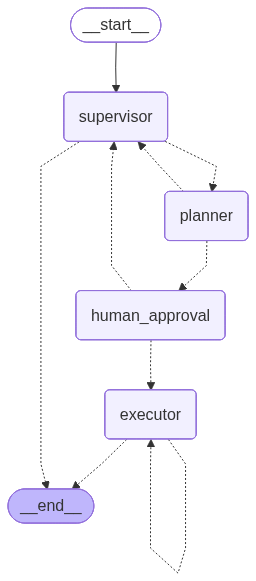

In [3]:
from IPython.display import Image, display
graph = build_graph(context=context)
display(Image(graph.get_graph().draw_mermaid_png()))